# Hugging Face & Sampling — Opening the Box

**Problem it solves:** so far the model has been something behind an API. You cannot see a logit through an API, and you cannot see what temperature actually *does*.

**How it works:** load a real (small) model locally, run one forward pass, and look at the numbers it produces. Then write the sampling rules yourself.

**When it matters:** this is the notebook that connects [1_introduction](../../1_introduction/1_llm_setting.md)'s settings knobs to the code underneath them, and lets you measure the KV cache and attention from [3_llm_inference.md](../3_llm_inference.md) on a real model instead of a toy.

### Setup

```
pip install torch transformers
```

Two small models are used, both downloaded automatically the first time (a few hundred MB each):

- **`distilgpt2`** (~82M parameters) — a *base* model, for looking at internals.
- **`HuggingFaceTB/SmolLM2-360M-Instruct`** — a real *instruct* model, small enough to run on a laptop CPU.

Everything runs on CPU. A cell may take a few seconds — that slowness is itself part of the lesson.

## Step 1 — Load a model and look at its shape

`AutoTokenizer` and `AutoModelForCausalLM` are the two doors you will use forever. `from_pretrained` downloads the weights once and caches them.

Read the config numbers out loud — they are the same numbers you used in the KV cache formula.

In [1]:
import time

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL)
# attn_implementation="eager" so we can read the attention weights later on;
# the fast default (sdpa) never builds them as a tensor we can look at.
model = AutoModelForCausalLM.from_pretrained(MODEL, attn_implementation="eager")
model.eval()

cfg = model.config
print(f"model      : {MODEL}")
print(f"parameters : {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M")
print(f"layers     : {cfg.n_layer}")
print(f"heads      : {cfg.n_head}")
print(f"hidden size: {cfg.n_embd}   (head_dim = {cfg.n_embd // cfg.n_head})")
print(f"vocabulary : {cfg.vocab_size:,} tokens")
print(f"context    : {cfg.n_positions} tokens   <- tiny by 2026 standards")

kv_per_token = 2 * cfg.n_layer * cfg.n_head * (cfg.n_embd // cfg.n_head) * 2
print(f"\nKV cache for this model: {kv_per_token / 1024:.0f} KB per token"
      f"  (2 x {cfg.n_layer} layers x {cfg.n_head} heads x {cfg.n_embd // cfg.n_head} head_dim x 2 bytes)")

model      : distilgpt2
parameters : 82M
layers     : 6
heads      : 12
hidden size: 768   (head_dim = 64)
vocabulary : 50,257 tokens
context    : 1024 tokens   <- tiny by 2026 standards

KV cache for this model: 18 KB per token  (2 x 6 layers x 12 heads x 64 head_dim x 2 bytes)


## Step 2 — Text in, IDs out

`Ġ` is not a bug. GPT-2 style tokenizers mark a leading space that way, so ` France` (with a space) and `France` (without) are genuinely different tokens.

In [2]:
text = "The capital of France is"
ids = tokenizer.encode(text)

print(f"text  : {text!r}")
print(f"ids   : {ids}")
print(f"pieces: {tokenizer.convert_ids_to_tokens(ids)}")
print(f"back  : {tokenizer.decode(ids)!r}")

print("\nsame word, with and without a leading space:")
for variant in ["France", " France"]:
    print(f"  {variant!r:10s} -> {tokenizer.encode(variant)}")

print("\na word the tokenizer has never seen:")
print(f"  'kubectl' -> {tokenizer.convert_ids_to_tokens(tokenizer.encode('kubectl'))}")

text  : 'The capital of France is'
ids   : [464, 3139, 286, 4881, 318]
pieces: ['The', 'Ġcapital', 'Ġof', 'ĠFrance', 'Ġis']
back  : 'The capital of France is'

same word, with and without a leading space:
  'France'   -> [28572]
  ' France'  -> [4881]

a word the tokenizer has never seen:
  'kubectl' -> ['k', 'ub', 'ect', 'l']


## Step 3 — The logits: what the model actually outputs

A language model does **not** output text. It outputs one score — a **logit** — for every token in the vocabulary, at every position. 50,257 numbers per position here.

`softmax` turns the last row into probabilities. Everything you know as "temperature", "top-k" and "top-p" is just a rule for picking one entry out of that row.

In [3]:
inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
print(f"logits shape: {tuple(logits.shape)} = (batch, tokens, vocabulary)")

next_token_logits = logits[0, -1]            # the row for the LAST position
probs = torch.softmax(next_token_logits, dim=-1)

print(f"\nprobabilities sum to {probs.sum():.4f}\n")
print(f"top 10 candidates after {text!r}:")
top = torch.topk(probs, 10)
for prob, idx in zip(top.values, top.indices):
    bar = "#" * int(prob * 200)
    print(f"  {tokenizer.decode([idx]):>12s} {prob:.4f} {bar}")

logits shape: (1, 5, 50257) = (batch, tokens, vocabulary)

probabilities sum to 1.0000

top 10 candidates after 'The capital of France is':
           the 0.1178 #######################
          home 0.0823 ################
           now 0.0499 #########
             a 0.0493 #########
         being 0.0356 #######
           one 0.0211 ####
         known 0.0189 ###
          also 0.0188 ###
            in 0.0180 ###
            to 0.0140 ##


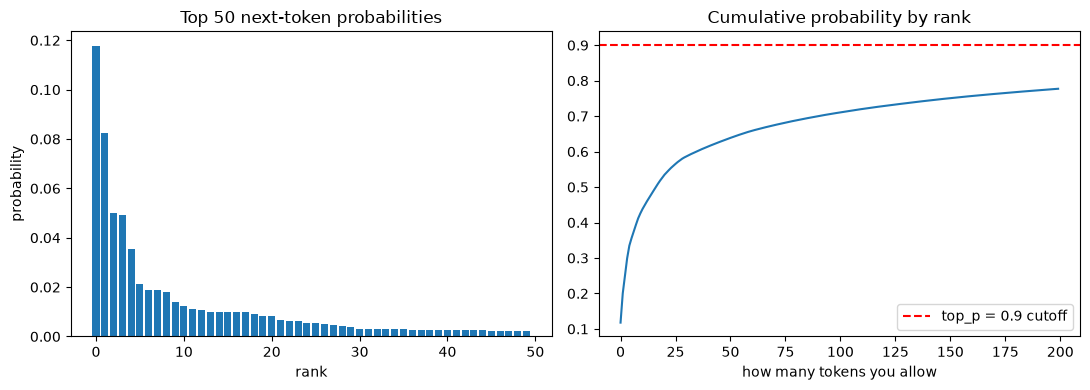

Out of 50,257 tokens, just 844 of them hold 90% of the probability.
That is what top_p = 0.9 keeps. Everything else is the long tail of nonsense.


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

top50 = torch.topk(probs, 50)
axes[0].bar(range(50), top50.values.numpy())
axes[0].set_title("Top 50 next-token probabilities")
axes[0].set_xlabel("rank")
axes[0].set_ylabel("probability")

sorted_probs = torch.sort(probs, descending=True).values
axes[1].plot(torch.cumsum(sorted_probs, dim=0)[:200].numpy())
axes[1].axhline(0.9, color="red", linestyle="--", label="top_p = 0.9 cutoff")
axes[1].set_title("Cumulative probability by rank")
axes[1].set_xlabel("how many tokens you allow")
axes[1].legend()

plt.tight_layout()
plt.show()

n_for_90 = int((torch.cumsum(sorted_probs, dim=0) < 0.9).sum()) + 1
print(f"Out of {len(probs):,} tokens, just {n_for_90} of them hold 90% of the probability.")
print("That is what top_p = 0.9 keeps. Everything else is the long tail of nonsense.")

## Step 4 — Write the sampling rules yourself

Same model, same prompt, four different rules for picking from that row of probabilities:

| Rule | What it does | Use it when |
|---|---|---|
| **greedy** | always take the highest | you want the same answer every time |
| **temperature** | flatten (high) or sharpen (low) the distribution before picking | you want more or less variety |
| **top-k** | keep the k best, ignore the rest | you want a hard cap on the choices |
| **top-p** | keep the smallest set that adds up to p | you want the cap to adapt to how confident the model is |

This is [1_llm_setting.md](../../1_introduction/1_llm_setting.md) with the covers off.

In [5]:
def generate(prompt, max_new_tokens=25, temperature=1.0, top_k=None, top_p=None, seed=0):
    '''Greedy when temperature == 0. Otherwise sample, with optional top-k / top-p.'''
    torch.manual_seed(seed)
    ids = tokenizer(prompt, return_tensors="pt").input_ids

    for _ in range(max_new_tokens):
        with torch.no_grad():
            next_logits = model(ids).logits[0, -1]

        if temperature == 0:
            next_id = torch.argmax(next_logits)
        else:
            probs = torch.softmax(next_logits / temperature, dim=-1)   # temperature

            if top_k is not None:
                values, indices = torch.topk(probs, top_k)             # keep the k best
                probs = torch.zeros_like(probs).scatter(0, indices, values)

            if top_p is not None:
                ordered, order = torch.sort(probs, descending=True)
                cumulative = torch.cumsum(ordered, dim=0)
                keep = cumulative - ordered < top_p                    # smallest set reaching p
                mask = torch.zeros_like(probs, dtype=torch.bool)
                mask[order[keep]] = True
                probs = probs * mask

            probs = probs / probs.sum()
            next_id = torch.multinomial(probs, num_samples=1)[0]

        ids = torch.cat([ids, next_id.view(1, 1)], dim=1)

    return tokenizer.decode(ids[0])


prompt = "The best thing about working with computers is"

print("GREEDY (temperature 0) - run it 100 times, get this 100 times")
print(" ", generate(prompt, temperature=0), "\n")

for t in (0.3, 1.0, 1.6):
    print(f"TEMPERATURE {t}")
    print(" ", generate(prompt, temperature=t), "\n")

print("TOP-K 10 (temperature 1.0)")
print(" ", generate(prompt, temperature=1.0, top_k=10), "\n")

print("TOP-P 0.9 (temperature 1.0)")
print(" ", generate(prompt, temperature=1.0, top_p=0.9))

GREEDY (temperature 0) - run it 100 times, get this 100 times


  The best thing about working with computers is that you can do it in a way that's easy to do, and it's easy to do it in a way that 

TEMPERATURE 0.3


  The best thing about working with computers is that you don't have to worry about the software. You just have to worry about the software. You don't have to 

TEMPERATURE 1.0


  The best thing about working with computers is that when it comes to communicating digital is that the physical medium fails to generate the true security investment that precludes us from traveling 

TEMPERATURE 1.6


  The best thing about working with computers is along gritty pilot arcsave stories...digitalbacks at derivative bipartisan failsgd Innovators Innovators investment wrestler pre-publicPlus earned 

TOP-K 10 (temperature 1.0)


  The best thing about working with computers is that when it comes to the right parts, the best thing about it is the best thing about working with computers is that when 

TOP-P 0.9 (temperature 1.0)


  The best thing about working with computers is that when it comes to communicating your mental health, physical health, sexual orientation, religious beliefs, gender identity or other characteristics that


Notice the shape of the failure at `temperature = 1.6`: the sentence falls apart into rare, unlikely tokens. That is not the model "being creative" — it is you telling it to draw from the long tail you just plotted.

And notice greedy: it is stable, and it tends to repeat itself. Both facts follow directly from the probability row, not from anything mysterious about the model.

## Step 5 — The KV cache, measured on a real model

`use_cache=True` is the default for a reason. Turning it off makes the model recompute every past token at every step — the exact O(n²) behaviour you built by hand in [3_kv_cache_and_inference_math.ipynb](3_kv_cache_and_inference_math.ipynb).

Same model, same greedy decoding, same output. Only the bookkeeping changes.

In [6]:
cache_prompt = tokenizer("Once upon a time in a small village", return_tensors="pt")

for n_tokens in (30, 60, 120):
    timings = {}
    for use_cache in (True, False):
        start = time.perf_counter()
        out = model.generate(**cache_prompt, max_new_tokens=n_tokens, do_sample=False,
                             use_cache=use_cache, pad_token_id=tokenizer.eos_token_id)
        timings[use_cache] = time.perf_counter() - start
    print(f"{n_tokens:4d} tokens | cache ON {timings[True]:5.2f}s | cache OFF {timings[False]:5.2f}s "
          f"| {timings[False] / timings[True]:4.1f}x slower without it")

print("\nThe gap grows with length - that is the O(n^2) vs O(n) difference, on real weights.")
print("Now imagine 8,000 tokens of context instead of 120.")

  30 tokens | cache ON  0.30s | cache OFF  0.48s |  1.6x slower without it


  60 tokens | cache ON  0.59s | cache OFF  1.23s |  2.1x slower without it


 120 tokens | cache ON  1.17s | cache OFF  3.50s |  3.0x slower without it

The gap grows with length - that is the O(n^2) vs O(n) difference, on real weights.
Now imagine 8,000 tokens of context instead of 120.


## Step 6 — Look at real attention weights

This is the payoff for `attn_implementation="eager"`: the actual attention matrices, from a real trained model, on the sentence from [1_attention_and_transformers.md](../1_attention_and_transformers.md).

Two things to look for:

1. **Heads do different jobs.** Same input, same layer, visibly different patterns.
2. **The first token gets a lot of weight in many heads.** That is the **attention sink** — heads that have nothing useful to attend to dump their weight on position 0. It is a known, studied behaviour, and it is part of why very long contexts degrade in the middle.

layers: 6, shape per layer: (1, 12, 13, 13)


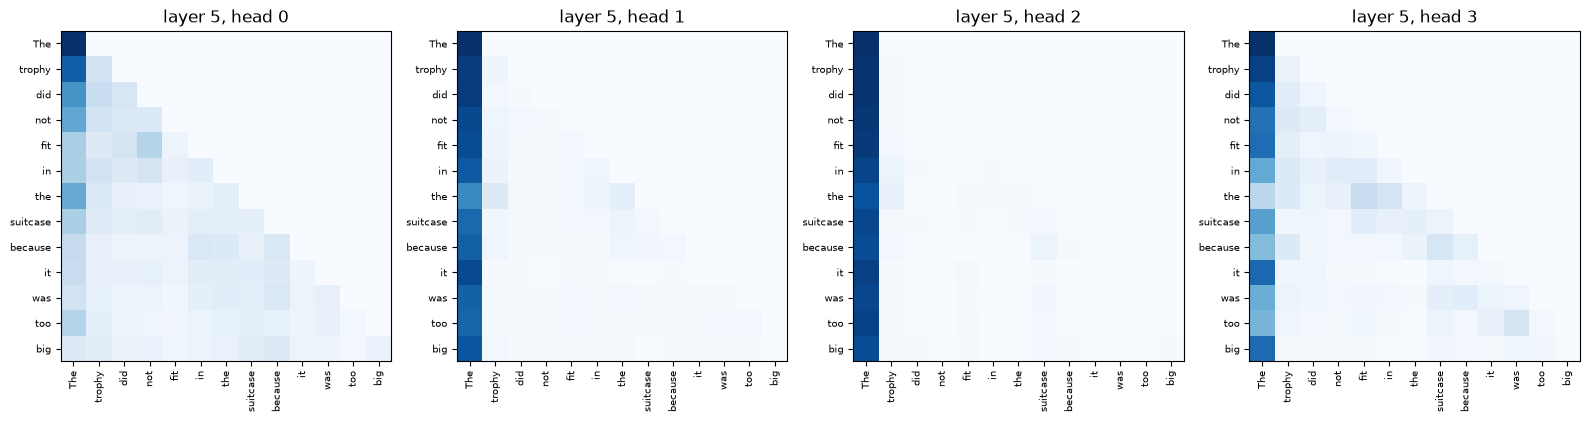

where 'it' looks, in layer 5 head 0:
  The        0.227
  because    0.128
  suitcase   0.106
  the        0.105
  in         0.102


In [7]:
sentence = "The trophy did not fit in the suitcase because it was too big"
enc = tokenizer(sentence, return_tensors="pt")

with torch.no_grad():
    out = model(**enc, output_attentions=True)

attentions = out.attentions          # one tensor per layer: (batch, heads, tokens, tokens)
print(f"layers: {len(attentions)}, shape per layer: {tuple(attentions[0].shape)}")

labels = [t.replace("Ġ", "") for t in tokenizer.convert_ids_to_tokens(enc.input_ids[0])]
layer = len(attentions) - 1          # the last layer

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, head in zip(axes, range(4)):
    ax.imshow(attentions[layer][0, head].numpy(), cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"layer {layer}, head {head}")
    ax.set_xticks(range(len(labels)), labels, rotation=90, fontsize=7)
    ax.set_yticks(range(len(labels)), labels, fontsize=7)

plt.tight_layout()
plt.show()

it_position = labels.index("it")
head0 = attentions[layer][0, 0, it_position]
print(f"where 'it' looks, in layer {layer} head 0:")
for score, word in sorted(zip(head0.tolist(), labels), reverse=True)[:5]:
    print(f"  {word:10s} {score:.3f}")

Do not expect a neat "it → trophy" arrow. `distilgpt2` is small, and real models spread that work across many heads and layers. What you *should* take away is that the triangle is always lower-left (the causal mask, in the wild), and that heads clearly specialise.

## Step 7 — Base vs Instruct, and the chat template

`distilgpt2` is a **base** model: it continues text, it does not answer questions. `SmolLM2-360M-Instruct` has been through SFT and alignment, so it does.

An instruct model also carries a **chat template** — the exact special-token layout it was trained on. The cell below shows the templated string, the answer you get with it, and the answer you get without it. That difference is the whole lesson.

In [8]:
CHAT_MODEL = "HuggingFaceTB/SmolLM2-360M-Instruct"

chat_tokenizer = AutoTokenizer.from_pretrained(CHAT_MODEL)
chat_model = AutoModelForCausalLM.from_pretrained(CHAT_MODEL)
chat_model.eval()

c = chat_model.config
print(f"{CHAT_MODEL}")
print(f"  layers {c.num_hidden_layers} | query heads {c.num_attention_heads} "
      f"| KV heads {c.num_key_value_heads}  <- GQA: {c.num_attention_heads // c.num_key_value_heads} "
      f"queries share each KV pair")
print(f"  has a chat template: {chat_tokenizer.chat_template is not None}")

messages = [
    {"role": "system", "content": "You answer in one short sentence."},
    {"role": "user", "content": "Why is the sky blue?"},
]
templated = chat_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

print("\nwhat your neat message list REALLY becomes:")
print(repr(templated))

HuggingFaceTB/SmolLM2-360M-Instruct
  layers 32 | query heads 15 | KV heads 5  <- GQA: 3 queries share each KV pair
  has a chat template: True

what your neat message list REALLY becomes:
'<|im_start|>system\nYou answer in one short sentence.<|im_end|>\n<|im_start|>user\nWhy is the sky blue?<|im_end|>\n<|im_start|>assistant\n'


In [9]:
def answer(prompt_text, model_, tokenizer_, max_new_tokens=45):
    enc = tokenizer_(prompt_text, return_tensors="pt")
    with torch.no_grad():
        out = model_.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False,
                              pad_token_id=tokenizer_.eos_token_id)
    return tokenizer_.decode(out[0][enc.input_ids.shape[1]:], skip_special_tokens=True).strip()


print("WITH the chat template:")
print(" ", answer(templated, chat_model, chat_tokenizer), "\n")

print("WITHOUT it - the same question as raw text:")
print(" ", repr(answer("Why is the sky blue?", chat_model, chat_tokenizer)), "\n")

print("The base model (distilgpt2) on the same question:")
print(" ", repr(answer("Why is the sky blue?", model, tokenizer)))

WITH the chat template:


  The sky appears blue because of a phenomenon called Rayleigh scattering, where shorter wavelengths of light, such as blue and violet, are scattered more than longer wavelengths, such as red and orange. 

WITHOUT it - the same question as raw text:
  '' 

The base model (distilgpt2) on the same question:


  ''


**Both answers without a template came back empty — and that is the lesson, not a bug.**

Fed raw text with no `<|im_start|>user ... <|im_start|>assistant` scaffolding, the instruct model's most likely next token is "this document is finished" (the end-of-text token), so greedy decoding stops immediately. The model is not refusing; it simply never saw plain questions in that shape during its instruction tuning.

Same prompt, same weights, same settings. The only difference is the special tokens around it. That is why you always let the tokenizer build the string.


## Your turn — modify and debug on purpose

Guess first, then run.

1. In Step 3, change the prompt to `"The capital of Bangladesh is"`. Is the model as confident? Look at the top-10 list — confidence and correctness are **not** the same thing, and this is what a hallucination looks like from the inside.
2. In Step 4, run `temperature=0` twice and `temperature=1.0` twice with the same `seed`. Which one repeats exactly, and why?
3. In Step 4, set `top_k=1`. What is it now equivalent to? Explain why in one sentence.
4. In Step 4, combine `temperature=1.6, top_p=0.9`. Does top-p rescue the high temperature? What does that tell you about tuning both at once (the warning in [1_llm_setting.md](../../1_introduction/1_llm_setting.md))?
5. In Step 5, push `n_tokens` to 200. Does the gap grow linearly or faster? Predict before running.
6. In Step 6, plot layer 0 instead of the last layer. Are early-layer heads more local (looking at neighbours) or more global?
7. In Step 7, remove the system message. Does the answer change length or tone? Then write a system message that makes it answer like a pirate, and confirm the template is what carries it.
8. Without AI help: *explain what a logit is, and how temperature, top-k and top-p each change what happens to it.* Three sentences, no jargon you cannot define.